# Etapa 1 - Importações de bibliotecas e suas funções necessárias

In [19]:
import numpy as np
import torch
import torch.nn.functional as F
import torchvision
import matplotlib.pyplot as plt
from time import time
from torchvision import datasets, transforms
from torch import nn, optim
from torch.utils.data import DataLoader, random_split
from pathlib import Path

# Etapa 2 - Criar uma classe responsável para a transformação de dados

In [20]:
# Classe Wrapper para aplicar transformações diferentes
class ApplyTransform(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y
        
    def __len__(self):
        return len(self.subset)

# Etapa 3 - Transformação de dados para treinamento e validação (teste)

In [21]:
# 1. Definição das Transformações
transform_treino = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

transform_val = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor()
])

# 2. Carregamento do Dataset Principal (sem transform aqui!)
caminho = './dataset'
# Importante: Carregamos sem transform para aplicar depois no wrapper
dataset_completo = datasets.ImageFolder(root=caminho, transform=None)

# 3. Divisão do Dataset
train_size = int(0.8 * len(dataset_completo))
val_size = len(dataset_completo) - train_size

# random_split retorna diretamente os Subsets
subset_treino, subset_val = random_split(dataset_completo, [train_size, val_size])

# 4. Aplicando as transformações de forma independente
train_set = ApplyTransform(subset_treino, transform=transform_treino)
val_set = ApplyTransform(subset_val, transform=transform_val)

# 5. Loaders
train_loader = DataLoader(train_set, batch_size=16, shuffle=True)
val_loader = DataLoader(val_set, batch_size=16)

## Etapa 3.1 - Teste de verificação de dados carregados para treino e validação (teste)

In [34]:
for X, y in train_loader:
    print(f"Shape of X train [N, C, H, W]: {X.shape}")
    print(f"Shape of y train: {y.shape} {y.dtype}", end='\n\n')
    break

for X, y in val_loader:
    print(f"Shape of X validation [N, C, H, W]: {X.shape}")
    print(f"Shape of y validation: {y.shape} {y.dtype}")
    break

Shape of X train [N, C, H, W]: torch.Size([16, 3, 512, 512])
Shape of y train: torch.Size([16]) torch.int64

Shape of X validation [N, C, H, W]: torch.Size([16, 3, 512, 512])
Shape of y validation: torch.Size([16]) torch.int64


## Etapa 3.2 - Exibição de uma imagem aleatória armazenada em dados de treino

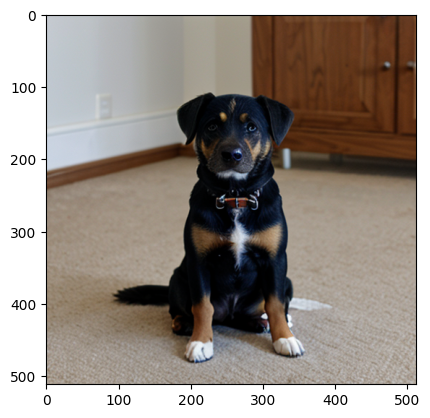

In [36]:
dataiter = iter(train_loader)
imagens, etiquetas = next(dataiter)
plt.imshow(imagens[0].permute(1, 2, 0).numpy().squeeze())

## Etapa 3.3 - Apenas verificar as dimensões e outras informações de imagens e etiquetas

In [24]:
print(imagens[0].shape)     # Verificar as dimensões do tensor de cada imagem
print(imagens[0].dtype)
print(imagens[0].dim())
print(imagens[0].stride(-1))
print(imagens[0].size(-1))
print(imagens[0].storage_offset(), end='\n\n')

print(etiquetas[0].shape)   # Verificar as dimensões do tensor de cada etiqueta
print(etiquetas[0].dtype)   

torch.Size([3, 512, 512])
torch.float32
3
1
512
0

torch.Size([])
torch.int64


# Etapa 4 - Função para quantificar o número de classes existentes no dataset

In [38]:
def qtd_classes(caminho_dir:Path) -> int:
    n_classes = 0
    try:
        for subpasta in caminho_dir.iterdir():
            if subpasta.is_dir():
                n_classes += 1
        return n_classes
    except Exception as e:
        print(f'Erro na execução.')
    
    

# Etapa 5 - Desenvolver uma classe para preparar o modelo de Rede Neural

In [39]:
caminho_dir = Path('./dataset')
n_classes = qtd_classes(caminho_dir)

class Modelo(nn.Module):
    def __init__(self):
        super(Modelo, self).__init__()
        # Camadas que 'olham' para os pixels vizinhos
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2) # Reduz 512 -> 256 -> 128
        
        # Após algumas reduções, usamos a camada Linear
        # 32 mapas de 128x128 pixels
        self.fc1 = nn.Linear(32 * 128 * 128, 128)
        self.fc2 = nn.Linear(128, n_classes) # FINALMENTE: 2 para Gato e Cachorro
        
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.shape[0], -1) # Achatamento automático
        x = F.relu(self.fc1(x))
        return F.log_softmax(self.fc2(x), dim=1)

# Etapa 6 - Criar função para o treinamento do modelo

In [27]:
def treino(modelo, trainloader, device):
    
    otimizador = optim.SGD(modelo.parameters(), lr=0.01, momentum=0.5)  # Define a política de atualização dos pesos e das bias
    inicio = time() # timer para sabermos quanto tempo levou o treino
    
    criterio = nn.NLLLoss() # definindo o critério para calcular a perda
    EPOCHS = 10 # número de epochs que o algoritmo rodará
    modelo.train()  # ativando o modo de treinamento do modelo
    
    for epoch in range(EPOCHS):
        perda_acumulada = 0 # inicialização da perda acumulada da epoch em questão
        
        for imagens, etiquetas in trainloader:
            
            otimizador.zero_grad()  # zerando os gradientes por conta do ciclo anterior
            
            output = modelo(imagens.to(device)) # colocando os dados no modelo
            perda_instantanea = criterio(output, etiquetas.to(device))  # calculando a perda da epoch em questão
            
            perda_instantanea.backward()    # back propagation a partir da perda
            
            otimizador.step()   # atualizando os pesos e a bias
            
            perda_acumulada += perda_instantanea.item() # atualização da perda acumulada
        
        else:
            print(f"Epoch {epoch+1} - Perda resultante: {perda_acumulada/len(trainloader)}")
    print(f"\nTempo de treino (em minutos) = {(time()-inicio)/60}")



# Etapa 7 - Criar função para a validação do modelo

In [28]:
def validacao(modelo, valloader, device, lista_classes:list[str]):
    conta_corretas, conta_todas = 0, 0
    # prepare to count predictions for each class
    correct_pred = {classname: 0 for classname in lista_classes}
    total_pred = {classname: 0 for classname in lista_classes}
    
    # 1. Modo de Avaliação (Essencial para desligar Dropout/Batchnorm)
    modelo.eval() 
    
    with torch.no_grad():
        for imagens, etiquetas in valloader:
            
            # 3. Inferência direta no lote
            logps = modelo(imagens.to(device))
            
            # 4. Cálculo de probabilidades e predição
            ps = torch.exp(logps)
            
            # Pega o índice da maior probabilidade (dimensão 1 são as colunas de classes)
            # Isso substitui o seu loop 'for i' e o 'list.index(max)'
            _, etiquetas_pred = torch.max(ps, dim=1)
            
            # 5. Comparação vetorial (muito mais rápido)
            conta_corretas += (etiquetas_pred.cpu() == etiquetas).sum().item()
            conta_todas += etiquetas.size(0)
            
        for data in val_loader:
            images, labels = data
            outputs = modelo(images)
            _, predictions = torch.max(outputs, 1)
            # collect the correct predictions for each class
            for label, prediction in zip(labels, predictions):
                if label == prediction:
                    correct_pred[lista_classes[label]] += 1
                total_pred[lista_classes[label]] += 1
            
    print(f"Total de imagens testadas = {conta_todas}")
    print(f"Acurácia do modelo = {conta_corretas*100/conta_todas:.2f}%", end='\n\n')
    
    # print accuracy for each class
    for classname, correct_count in correct_pred.items():
        accuracy = 100 * float(correct_count) / total_pred[classname]
        print(f'Acurácia por classe: {classname:5s} está em {accuracy:.1f} %')

# Etapa 8 - Preparar o modelo e o device

In [29]:
modelo = Modelo()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

modelo.to(device)

Modelo(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=524288, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
)

# Etapa 9 - Treinar o modelo com os dados de treinamento

In [30]:
treino(modelo=modelo, trainloader=train_loader, device=device)

Epoch 1 - Perda resultante: 0.7112914419174194
Epoch 2 - Perda resultante: 0.6299859076738358
Epoch 3 - Perda resultante: 0.5237097960710525
Epoch 4 - Perda resultante: 0.4468438589572907
Epoch 5 - Perda resultante: 0.39050672098994255
Epoch 6 - Perda resultante: 0.31757148206233976
Epoch 7 - Perda resultante: 0.3015433297306299
Epoch 8 - Perda resultante: 0.25228679277002813
Epoch 9 - Perda resultante: 0.2487943321466446
Epoch 10 - Perda resultante: 0.21762266874313355

Tempo de treino (em minutos) = 19.858275059858958


# Etapa 10 - Buscar o nome das classes existentes

In [31]:
lista_classes = list()
caminho_dir = Path('./dataset')

for sub_dir in caminho_dir.iterdir():
    if (sub_dir.is_dir()) and (sub_dir not in lista_classes):
        nome_sub_dir = sub_dir.name
        lista_classes.append(nome_sub_dir)
print(f"Classes: {lista_classes}")

Classes: ['Cachorro', 'Gato']


# Etapa 11 - Validar o modelo com os dados de validação

In [32]:
validacao(modelo=modelo, valloader=val_loader, device=device, lista_classes=lista_classes)

Total de imagens testadas = 200
Acurácia do modelo = 87.50%

Acurácia por classe: Cachorro está em 94.0 %
Acurácia por classe: Gato  está em 81.0 %
